In [6]:
import numpy as np
import numpy.testing as npt

from scipy import stats
from scipy.stats import t,ttest_ind
from scipy.stats import f
from scipy.stats import f_oneway
from scipy.stats import pearsonr

import statsmodels.api as sm
from statsmodels.regression._prediction import get_prediction
from statsmodels.stats.outliers_influence import OLSInfluence,MLEInfluence
from statsmodels.graphics.gofplots import qqplot_2samples,ProbPlot,qqplot
import pandas as pd
from patsy import dmatrices
from numpy.testing import assert_almost_equal, assert_allclose
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import os
# some_file.py
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                      get_variance_inflation_factors

In [7]:
path = os.path.join(os.getcwd(), 'DataSet', 'DeliveryTimeData.txt')
df = pd.read_csv(path)
print(df.columns)

Index(['Obs', 'DlvrTime_Y', 'NumCase_X1', 'Dist_X2'], dtype='object')


In [8]:
formulas = 'DlvrTime_Y ~ NumCase_X1 + Dist_X2'

y, X = dmatrices(
                 formula_like = formulas, 
                 data=df,
                 return_type='dataframe'
                 )

huber_t = sm.RLM(y,X, M=sm.robust.norms.HuberT(t= 1.48))
hub_results = huber_t.fit()
tableDispFormatt('Robust Regressions Criterion = HuberT')
print(hub_results.params)
#print(hub_results.chisq)
#print(hub_results.weights)

=============================== Robust Regressions Criterion = HuberT ======================
Intercept     3.433526
NumCase_X1    1.473726
Dist_X2       0.014500
dtype: float64


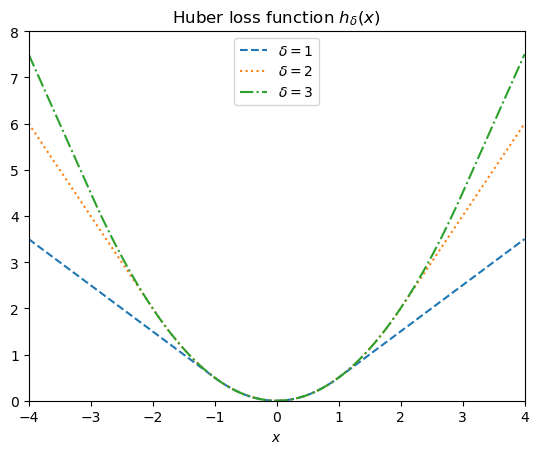

In [9]:
import numpy as np
from scipy.special import huber
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 500)

'''
Qus How to assume delta for x ?
'''
deltas = [1, 2, 3]

linestyles = ["dashed", "dotted", "dashdot"]
fig, ax = plt.subplots()
combined_plot_parameters = list(zip(deltas, linestyles))
#print(combined_plot_parameters)

# Get huber loss for each delta
for delta, style in combined_plot_parameters:
    ax.plot(x, huber(delta, x), label=fr"$\delta={delta}$", ls=style)

ax.legend(loc="upper center")
ax.set_xlabel("$x$")
ax.set_title(r"Huber loss function $h_{\delta}(x)$")
ax.set_xlim(-4, 4)
ax.set_ylim(0, 8)
plt.show()